# Core 03 — Decision Tree (Iris)

Notebook *industrial-grade* orienté interprétabilité : EDA, baseline, pruning (ccp_alpha),
visualisation, extraction de règles, validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
np.random.seed(42); sns.set_theme(style='whitegrid')


## 1) Data

In [2]:
iris=load_iris(as_frame=True)
df=iris.frame.copy()
df.rename(columns={'target':'species_id'}, inplace=True)
df['species']=df['species_id'].map({i:n for i,n in enumerate(iris.target_names)})
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2) EDA

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  species_id  
species                                   
setosa                 0.246         0.0  
versicolor             1.326         1.0  
virginica              2.026         2.0  


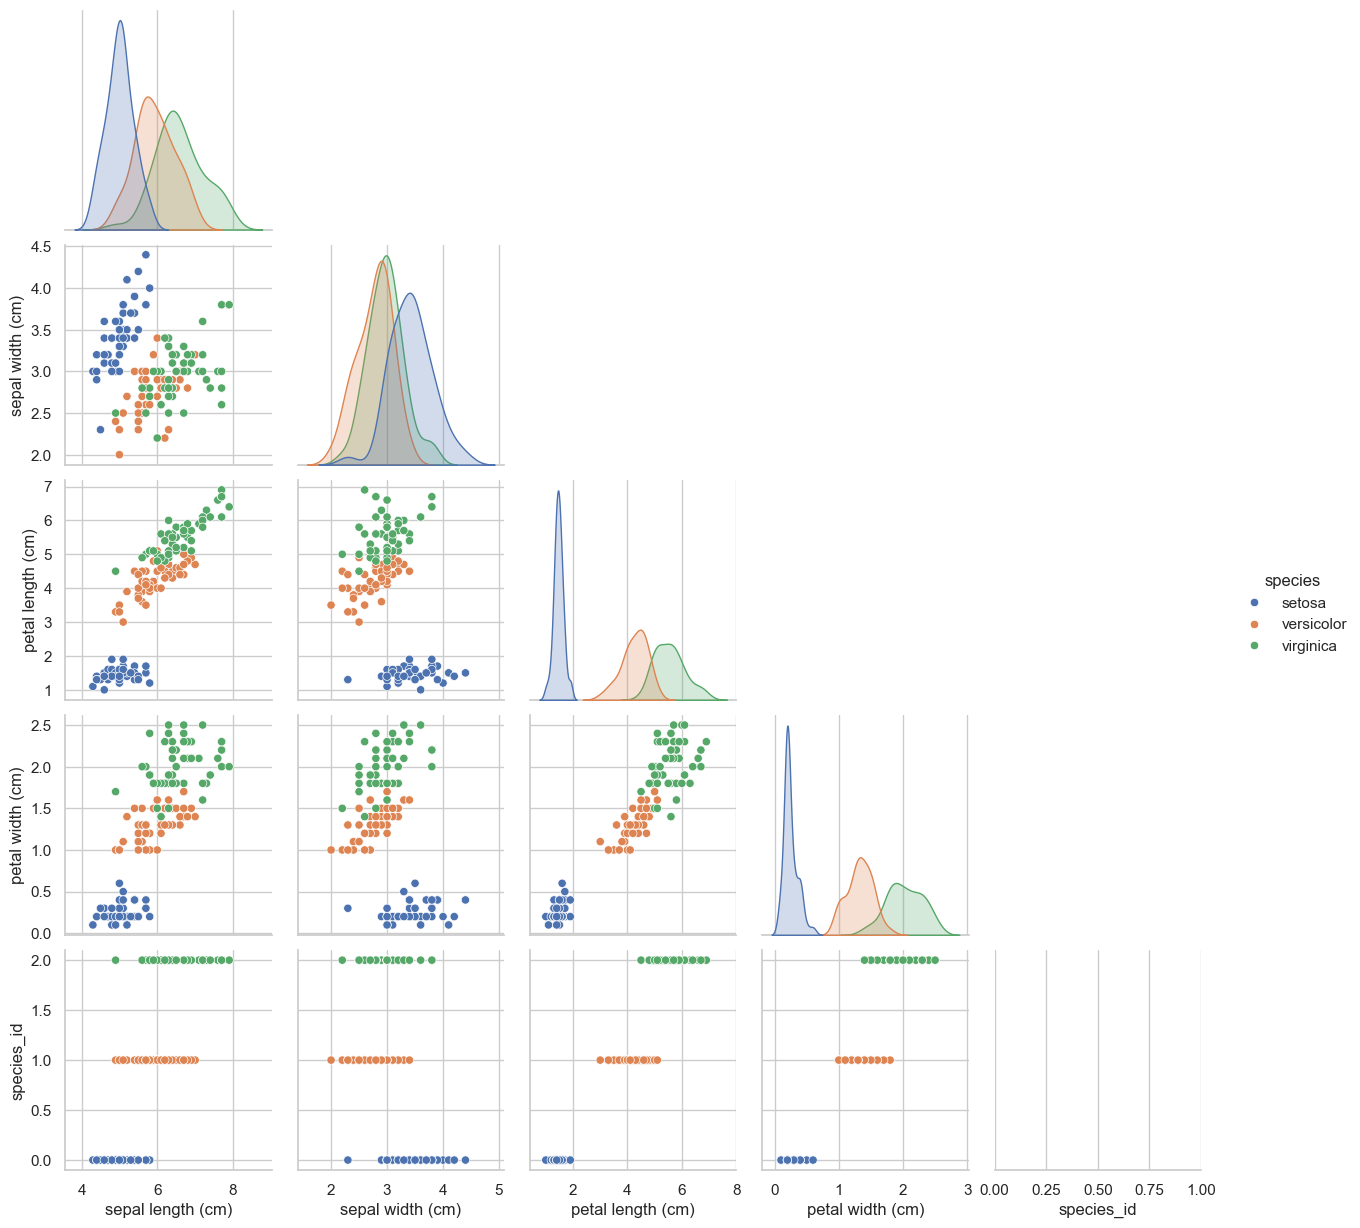

In [3]:
print(df.groupby('species').mean(numeric_only=True))
sns.pairplot(df, hue='species', corner=True)
plt.show()


## 3) Train/test + baseline

In [4]:
X=df[iris.feature_names]; y=df['species_id']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
base=DecisionTreeClassifier(random_state=42)
base.fit(Xtr,ytr)
pred=base.predict(Xte)
print('acc', accuracy_score(yte,pred))
print(classification_report(yte,pred, target_names=iris.target_names))
confusion_matrix(yte,pred)


acc 0.8947368421052632
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



array([[12,  0,  0],
       [ 0, 12,  1],
       [ 0,  3, 10]], dtype=int64)

## 4) Cost-complexity pruning path

In [5]:
path = base.cost_complexity_pruning_path(Xtr, ytr)
ccp_alphas = path.ccp_alphas
pd.Series(ccp_alphas).describe()


count    7.000000
mean     0.093035
std      0.143037
min      0.000000
25%      0.007685
50%      0.013393
75%      0.143112
max      0.336256
dtype: float64

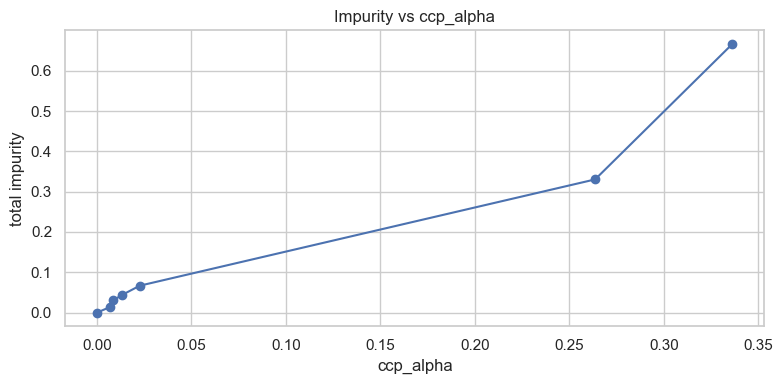

In [6]:
fig=plt.figure(figsize=(8,4))
plt.plot(ccp_alphas, path.impurities, marker='o')
plt.title('Impurity vs ccp_alpha')
plt.xlabel('ccp_alpha'); plt.ylabel('total impurity')
plt.tight_layout(); plt.show()


## 5) Grid search (depth + leaf + ccp_alpha)

In [7]:
param={
 'max_depth':[2,3,4,5,None],
 'min_samples_leaf':[1,2,3,4],
 'ccp_alpha':[0.0, 0.001, 0.003, 0.006, 0.01, 0.02]
}
gs=GridSearchCV(DecisionTreeClassifier(random_state=42), param, cv=5)
gs.fit(Xtr,ytr)
gs.best_params_, gs.best_score_


({'ccp_alpha': 0.01, 'max_depth': 4, 'min_samples_leaf': 1},
 0.9379446640316205)

## 6) Best model evaluation + interpretability

In [8]:
best=gs.best_estimator_
pred=best.predict(Xte)
print('acc', accuracy_score(yte,pred))
print(classification_report(yte,pred, target_names=iris.target_names))
cm=confusion_matrix(yte,pred)
cm


acc 0.9210526315789473
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



array([[12,  0,  0],
       [ 0, 12,  1],
       [ 0,  2, 11]], dtype=int64)

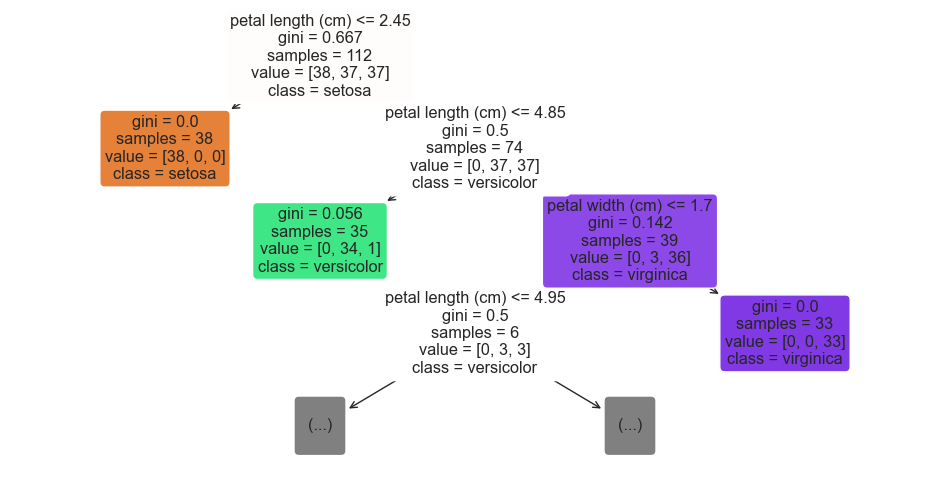

In [9]:
fig=plt.figure(figsize=(12,6))
plot_tree(best, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True, max_depth=3)
plt.show()


In [10]:
rules = export_text(best, feature_names=iris.feature_names)
print(rules[:1400])


|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.85
|   |   |--- class: 1
|   |--- petal length (cm) >  4.85
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



In [11]:
imp=pd.DataFrame({'feature':iris.feature_names,'importance':best.feature_importances_}).sort_values('importance', ascending=False)
imp


,feature,importance
2,petal length (cm),0.964356
3,petal width (cm),0.035644
0,sepal length (cm),0.000000
1,sepal width (cm),0.000000


## Conclusion
Arbre pruné, stable, et interprétable (règles + importance + validation).